# Getting Started

This example shows the basic functions of `tesspy`, which are five types of tessellations: square, hexagon, adaptive squares, voronoi diagrams and city blocks. We have selected the city of **Frankfurt am Main** in Germany to demonstrate tessellation.

## Installation

### Requirements

`tesspy` requires **Python 3.11+**.

### Creating a new environment and installing tesspy

We recommend using [uv](https://docs.astral.sh/uv/) for environment and package management.

Create a new virtual environment and activate it:

```shell
uv venv tesspy_env
source tesspy_env/bin/activate
```

Install `tesspy` with the tutorial dependencies:

```shell
uv pip install "tesspy[examples]"
```

This installs `tesspy` along with `contextily`, `esda`, `libpysal`, `seaborn`, `statsmodels`, `jupyterlab`, and `ipykernel` — everything you need to run the example notebooks.

## Tessellation of Frankfurt am Main

We start by importing the `Tessellation` object from `tesspy` module:

In [1]:
from tesspy import Tessellation

## Defining the area

There are different ways to define the area. The most straightforward way is passing an address.

In [3]:
ffm = Tessellation("Frankfurt am Main")

With `.get_polygon()` method, we can retrieve the polygon. This is in the form of a GeoPandas GeoDataFrame. We visualize the polygon to make sure data collection was successful and correct:

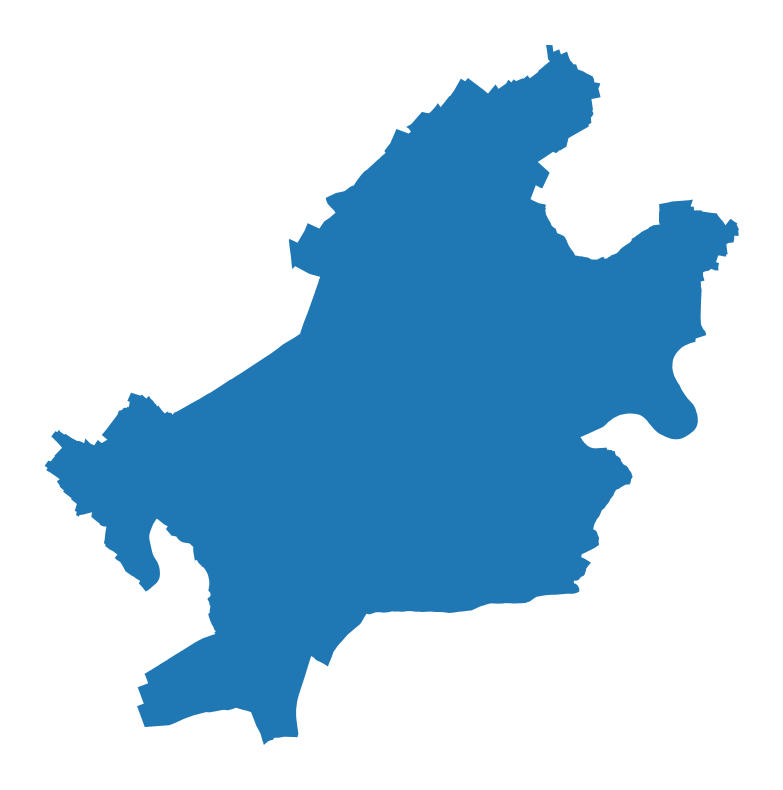

In [4]:
ffm.get_polygon().plot(figsize=(10, 10)).set_axis_off();

The polygon shows the city of Frankfurt. Note that the `CRS` of the GeoPandas is `EPSG:4326`. We can double-check that:

In [5]:
print(ffm.get_polygon().crs)

epsg:4326


It is already ready for tessellation.

## Squares
The first tessellation method is the square grid. It creates (almost) equal squares that cover the whole area surface. In order to set the size, we need to pass a `resolution`. 
This value is usually between 1 and 21. Larger values mean smaller squares and consequently a finer tessellation.
For example, with a `resolution=13`, we have:

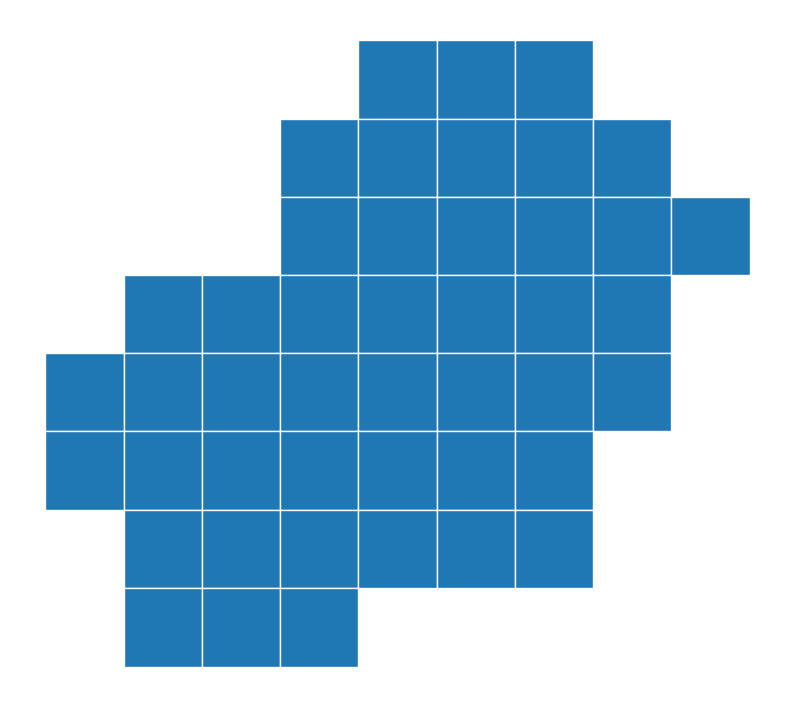

In [6]:
ffm_sqr_13 = ffm.squares(13)
ffm_sqr_13.plot(lw=1, edgecolor="w", figsize=(10, 10)).set_axis_off();

In [7]:
ffm_sqr_13.head()

,geometry,quadkey
0,"POLYGON ((8.48145 50.09239, 8.48145 50.12058, ...",1202033020220
1,"POLYGON ((8.48145 50.06419, 8.48145 50.09239, ...",1202033020222
2,"POLYGON ((8.52539 50.12058, 8.52539 50.14875, ...",1202033020203
3,"POLYGON ((8.52539 50.09239, 8.52539 50.12058, ...",1202033020221
4,"POLYGON ((8.52539 50.06419, 8.52539 50.09239, ...",1202033020223


The square grid with a `resolution=15` look like this:

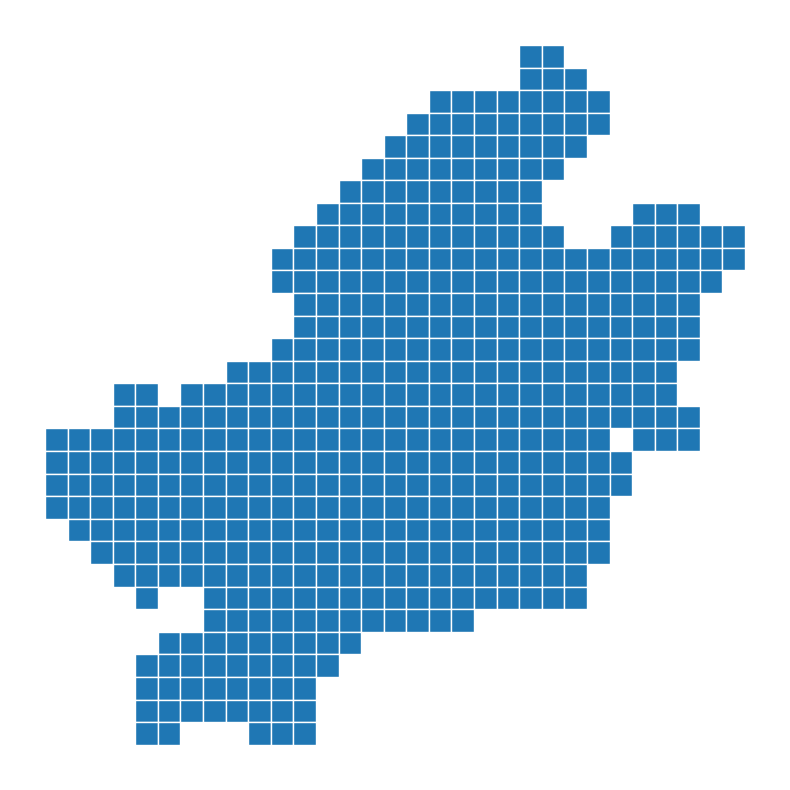

In [8]:
ffm_sqr_15 = ffm.squares(15)
ffm_sqr_15.plot(lw=1, edgecolor="w", figsize=(10, 10)).set_axis_off();

As it can be seen the number of square are relatively higher when resolution is higher. We can check the number of squares for each resolution:

In [9]:
print("Resolution=13  ==>  Number of squares:  ", ffm_sqr_13.shape[0])
print("Resolution=15  ==>  Number of squares:  ", ffm_sqr_15.shape[0])

Resolution=13  ==>  Number of squares:   45
Resolution=15  ==>  Number of squares:   488


## hexagons

The next method is hexagons. Similar to squares, this method creates (almost) equal shapes to cover the area. A slight difference is that the algorithm finds the optimal number of hexagons, and not all the surface is covered. Therefore, there may be some areas on the borders which are left behind.

Similarly, we need to pass a resolution to set the hexagon sizes. The larger numbers mean smaller hexagons. A suitable value is usually between 5 and 15.
Here is the hexagon tessellation with `resolution=7`:

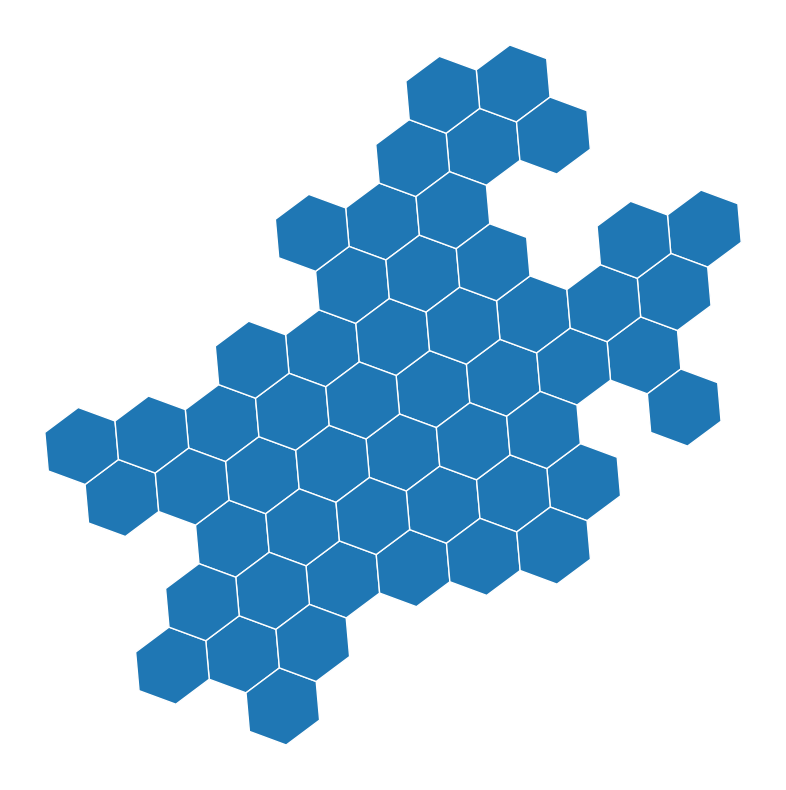

In [10]:
ffm_hex_7 = ffm.hexagons(7)
ffm_hex_7.plot(lw=1, edgecolor="w", figsize=(10, 10)).set_axis_off();

In [11]:
ffm_hex_7.head()

,hex_id,geometry
0,871faea12ffffff,"POLYGON ((8.59102 50.13931, 8.59263 50.12762, ..."
1,871faea81ffffff,"POLYGON ((8.60069 50.06918, 8.6023 50.05748, 8..."
2,871faeaf0ffffff,"POLYGON ((8.71469 50.09872, 8.71628 50.08702, ..."
3,871faeaa0ffffff,"POLYGON ((8.54355 50.1166, 8.54517 50.10492, 8..."
4,871faea00ffffff,"POLYGON ((8.66701 50.20046, 8.66861 50.18878, ..."


At the next resolution, in this case, `resolution=8`, each hexagon is divided into 7 sub-hexagons. This means the total number of hexagons is (almost) 7 times more when resolution increments one unit. Following plot shows the hexagons of Frankfurt with `resolution=8`:

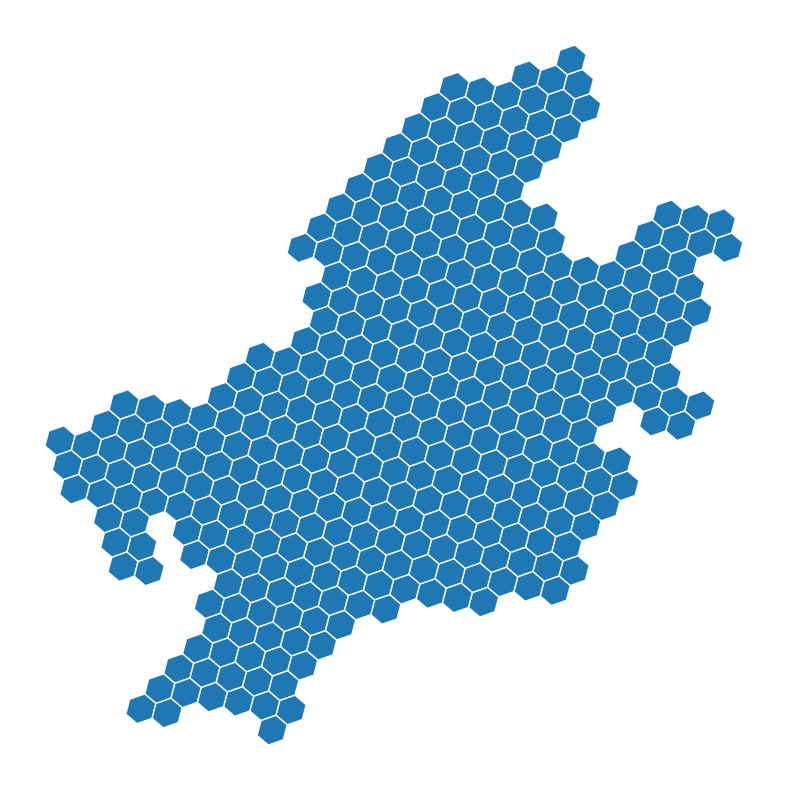

In [12]:
ffm_hex_8 = ffm.hexagons(8)
ffm_hex_8.plot(lw=1, edgecolor="w", figsize=(10, 10)).set_axis_off();

In [13]:
print("Resolution=7  ==>  Number of hexagons:  ", ffm_hex_7.shape[0])
print("Resolution=8  ==>  Number of hexagons:  ", ffm_hex_8.shape[0])

Resolution=7  ==>  Number of hexagons:   53
Resolution=8  ==>  Number of hexagons:   367


## Adaptive squares

Adaptive squares are an extension of regular squares. This method starts with relatively large squares and uses the spatial data, i.e., Points of Interests (POI), to divide the high-density squares into 4 subsquares. The division of squares is done until a specific threshold for POI count per square is reached.

The spatial data are retrieved from OpenStreetMap (OSM). We can use which POI categories we want to use. The selected POI categories should be passed as a list. These categories are the OSM primary categories, which represent physical objects on the map. More information can be found at this [link](https://wiki.openstreetmap.org/wiki/Map_features).

You can see the top-level categories by:

In [14]:
print(Tessellation.osm_primary_features())

['aerialway', 'aeroway', 'amenity', 'barrier', 'boundary', 'building', 'craft', 'emergency', 'geological', 'healthcare', 'highway', 'historic', 'landuse', 'leisure', 'man_made', 'military', 'natural', 'office', 'place', 'power', 'public_transport', 'railway', 'route', 'shop', 'sport', 'telecom', 'tourism', 'water', 'waterway']


We build the adaptive squares using only `amenity` data:

In [ ]:
# Adaptive Squares using only amenity data
ffm_asq = ffm.adaptive_squares(
    start_resolution=13,
    poi_categories=["amenity"],
    threshold=None,
    verbose=True,
)

We visualize the adaptive squares:

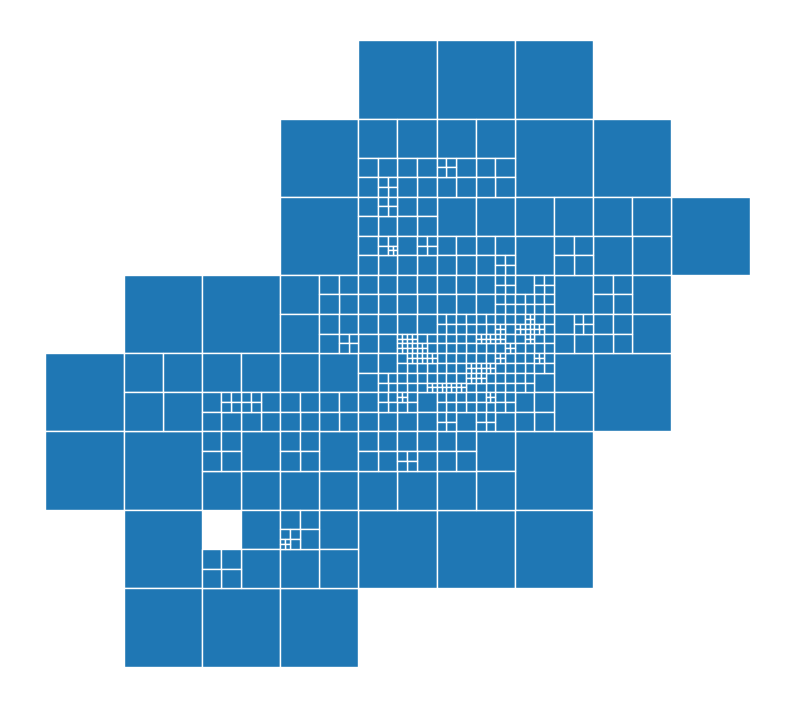

In [16]:
ffm_asq.plot(lw=1, edgecolor="w", figsize=(10, 10)).set_axis_off();

In [17]:
ffm_asq.head()

,quadkey,geometry,count
0,1202033020220,"POLYGON ((8.48145 50.09239, 8.48145 50.12058, ...",1
1,1202033020222,"POLYGON ((8.48145 50.06419, 8.48145 50.09239, ...",1
2,1202033020203,"POLYGON ((8.52539 50.12058, 8.52539 50.14875, ...",1
3,1202033020223,"POLYGON ((8.52539 50.06419, 8.52539 50.09239, ...",122
4,1202033022001,"POLYGON ((8.52539 50.03597, 8.52539 50.06419, ...",1


## Voronoi-Diagrams

Voronoi-Diagram is a method for tessellation that uses irregular shapes to cover the area. In this method, we have a given set of points, called generators. For each generator, there is a polygon that contains the area that is closer to this generator than other generators.

In this context, the generators are the POI, coming from OSM as explained for adaptive squares. Usually, the number of POI is larger than the required number of polygons. So, we can use a clustering method to cluster POI in the first step and then use the cluster centroids as the generator points.

In the example below, we use `shop` and `public_transport` as POI. We use the `k-means` clustering algorithm to cluster the POI and build the generators. The number of polygons is set to 100.

In [18]:
ffm_voronoi = ffm.voronoi(
    cluster_algo="k-means",
    poi_categories=["shop", "public_transport"],
    n_polygons=100,
    timeout=300,
    verbose=True,
)

2026-02-22 13:11:43 | INFO | tesspy.tessellation | event=voronoi.start cluster_algo=k-means poi_categories=2 n_polygons=100 min_cluster_size=15 timeout_s=300
2026-02-22 13:11:43 | INFO | tesspy.data.poi | event=poi.fetch.start poi_categories=2 timeout_s=300
2026-02-22 13:11:44 | INFO | tesspy.data.poi | event=poi.fetch.done features=9066 duration_s=0.729
2026-02-22 13:11:44 | INFO | tesspy.data.poi | event=poi.parse.done poi_count=9066
2026-02-22 13:11:44 | INFO | tesspy.tessellation | event=voronoi.cluster.start algo=kmeans
2026-02-22 13:11:44 | INFO | tesspy.tessellation | event=voronoi.polygons.create generators=100
2026-02-22 13:11:44 | INFO | tesspy._validators | event=geometry.multipolygon.explode
2026-02-22 13:11:44 | INFO | tesspy.tessellation | event=voronoi.done polygons=104 duration_s=0.893


We can now plot and visualize the voronoi polygons:

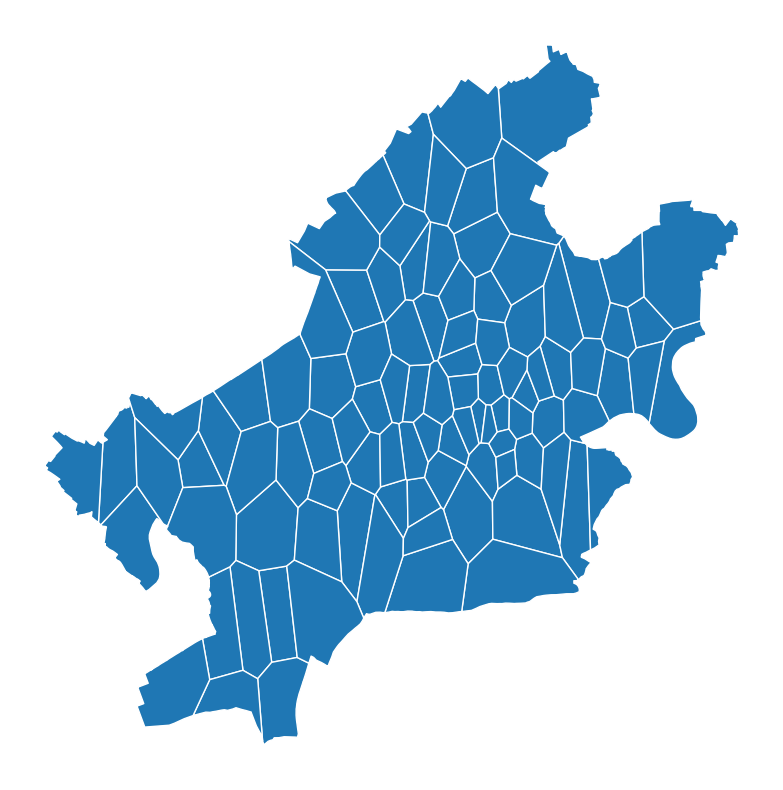

In [19]:
ffm_voronoi.plot(lw=1, edgecolor="w", figsize=(10, 10)).set_axis_off();

In [20]:
ffm_voronoi.head()

,voronoi_id,geometry
0,voronoiID0,"POLYGON ((8.65645 50.13146, 8.64656 50.14981, ..."
1,voronoiID1,"POLYGON ((8.57376 50.06808, 8.58697 50.06948, ..."
2,voronoiID2,"POLYGON ((8.70816 50.15448, 8.70899 50.13891, ..."
3,voronoiID3,"POLYGON ((8.55745 50.09394, 8.53793 50.09322, ..."
4,voronoiID4,"POLYGON ((8.67768 50.10649, 8.67379 50.11775, ..."


In [21]:
print("Number of polygons ==> ", len(ffm_voronoi))

Number of polygons ==>  104


## City blocks
The last tessellation method is city blocks. We define city blocks as the smallest area surrounded by street segments. This method gets the road network data from OSM and generates polygons based on the roads. We use hierarchical clustering to merge a group of contiguous polygons. This guarantees that tiny polygons like road islands are not identified as single polygons. The number of desired polygons can be passed. This would be an approximation. The final number of city blocks could slightly vary.

For example, the following is the example of city blocks for Frankfurt:

In [23]:
ffm_cb = ffm.city_blocks(
    n_polygons=500, detail_deg=None, verbose=True
)

2026-02-22 13:11:57 | INFO | tesspy.tessellation | event=city_blocks.start n_polygons=500 detail_deg=None
2026-02-22 13:11:57 | INFO | tesspy.data.roads | event=roads.filter.selected detail_deg=None filter=['highway'~'motorway|trunk|primary|secondary|tertiary|residential|unclassified|motorway_link|trunk_link|primary_link|secondary_link|living_street|pedestrian|track|bus_guideway|footway|path|service|cycleway']
2026-02-22 13:11:57 | INFO | tesspy.data.roads | event=roads.fetch.start
2026-02-22 13:12:33 | INFO | tesspy.data.roads | event=roads.fetch.done segments=138212 duration_s=35.724
2026-02-22 13:12:33 | INFO | tesspy.tessellation | event=city_blocks.blocks.create.start
2026-02-22 13:12:36 | INFO | tesspy.tessellation | event=city_blocks.merge.start
2026-02-22 13:12:40 | INFO | tesspy.tessellation | event=city_blocks.done polygons=519 duration_s=43.006


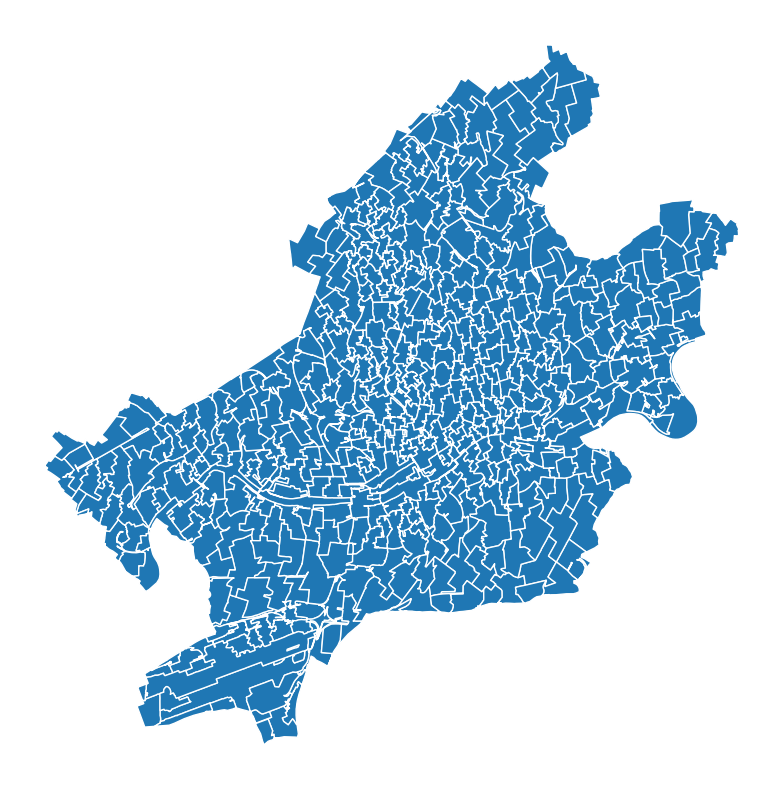

In [24]:
ffm_cb.plot(lw=1, edgecolor="w", figsize=(10, 10)).set_axis_off();

In [25]:
ffm_cb.head()

,cityblock_id,geometry
0,cityblockID0,"POLYGON ((8.63062 50.06558, 8.63047 50.06569, ..."
1,cityblockID1,"POLYGON ((8.68842 50.05814, 8.68835 50.05814, ..."
2,cityblockID2,"POLYGON ((8.74643 50.14373, 8.74637 50.14383, ..."
3,cityblockID3,"POLYGON ((8.58457 50.11584, 8.58448 50.11583, ..."
4,cityblockID4,"POLYGON ((8.55749 50.04837, 8.55748 50.04841, ..."


In [26]:
print("Number of polygons ==> ", len(ffm_cb))

Number of polygons ==>  519
